In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Cargamos el archivo
data=pd.read_csv("Plazas_Limpio.csv")

#Mostramos los primeros registros
data.head()

,Fecha Origen,Nombre,Producto,Asesor,Origen,Seguimiento,Cita efetiva,PDM,SDC,Estatus,¿Por que no hay seguimiento?,¿Por que no ha visitado la agencia?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo solicitud de credito?,¿Por que no se ha formalizado la compra?,Unnamed: 16
0,2025-05-06 18:30:00,Alejandro Fernandez,AION,NANCY OLASCOAGA CASTILLO,PLAZA ANGELOPOLIS,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Recibe recurso a finales de junio, proyección ...",No aplica,No aplica,No aplica,Sin información
1,2025-05-06 18:00:00,David Israel,EMKOO,JOSE EDUARDO PARADA DURAN,PLAZA ANGELOPOLIS,1.0,0.0,0.0,0.0,Finalizado,Si hay seguimiento,Dejo de contestar,No aplica,No aplica,No aplica,Sin información
2,2025-05-06 13:50:00,Rosendo Ceron,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No aplica,No aplica,No aplica,Sin información
3,2025-05-06 13:47:00,Fausto Ochoa Martinez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No aplica,No aplica,No aplica,Sin información
4,2025-05-06 13:43:00,Brigida Lara Perez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,1.0,0.0,0.0,0.0,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No aplica,No aplica,No aplica,Sin información


In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Fecha Origen                              303 non-null    object
 1   Nombre                                    303 non-null    object
 2   Producto                                  303 non-null    object
 3   Asesor                                    303 non-null    object
 4   Origen                                    303 non-null    object
 5   Seguimiento                               303 non-null    object
 6   Cita efetiva                              303 non-null    object
 7   PDM                                       303 non-null    object
 8   SDC                                       303 non-null    object
 9   Estatus                                   303 non-null    object
 10  ¿Por que no hay seguimiento?              303 non-

In [4]:
#Verificamos los valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Fecha Origen                                0
Nombre                                      0
Producto                                    0
Asesor                                      0
Origen                                      0
Seguimiento                                 0
Cita efetiva                                0
PDM                                         0
SDC                                         0
Estatus                                     0
¿Por que no hay seguimiento?                0
¿Por que no ha visitado la agencia?         0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo solicitud de credito?      0
¿Por que no se ha formalizado la compra?    0
Unnamed: 16                                 0
dtype: int64

In [5]:
#Convertimos las columnas cuantitativas a valores numéricos
data["Seguimiento"] = data["Seguimiento"].replace("False", 0).astype(float)
data["Cita efetiva "] = data["Cita efetiva "].replace("False", 0).astype(float)
data["PDM"] = data["PDM"].replace("False", 0).astype(float)
data["SDC"] = data["SDC"].replace("False", 0).astype(float)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Fecha Origen                              303 non-null    object 
 1   Nombre                                    303 non-null    object 
 2   Producto                                  303 non-null    object 
 3   Asesor                                    303 non-null    object 
 4   Origen                                    303 non-null    object 
 5   Seguimiento                               303 non-null    float64
 6   Cita efetiva                              303 non-null    float64
 7   PDM                                       303 non-null    float64
 8   SDC                                       303 non-null    float64
 9   Estatus                                   303 non-null    object 
 10  ¿Por que no hay seguimiento?          

In [6]:
#Creo 2 dataframe para poder procesar los outliers
cuantitativas= data.iloc[ : , 5:9 ]
cualitativas= data.iloc[ : , [0,1,2,3,4,9,10,11,12,13,14,15] ]

<Figure size 1500x800 with 0 Axes>

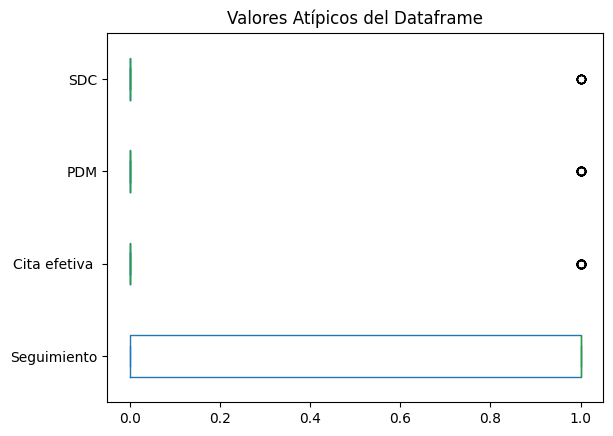

In [7]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [8]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Seguimiento      2.083387
Cita efetiva     0.927442
PDM              0.852367
SDC              0.539845
dtype: float64
Limite inferior permitido Seguimiento     -0.756654
Cita efetiva    -0.755825
PDM             -0.707153
SDC             -0.480439
dtype: float64


In [9]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data3= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,Seguimiento,Cita efetiva,PDM,SDC
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
298,0.0,0.0,0.0,0.0
299,0.0,0.0,0.0,0.0
300,0.0,0.0,0.0,0.0
301,0.0,0.0,0.0,0.0


In [10]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data3.isnull().sum()
valores_nulos

Seguimiento       0
Cita efetiva     26
PDM              22
SDC               9
dtype: int64

In [11]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data3.copy()
data_clean=data_clean.fillna(round(data3.mean(),1))
data_clean

,Seguimiento,Cita efetiva,PDM,SDC
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
298,0.0,0.0,0.0,0.0
299,0.0,0.0,0.0,0.0
300,0.0,0.0,0.0,0.0
301,0.0,0.0,0.0,0.0


In [12]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

Seguimiento      0
Cita efetiva     0
PDM              0
SDC              0
dtype: int64

In [13]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Seguimiento      2.5
Cita efetiva     0.0
PDM              0.0
SDC              0.0
dtype: float64
Limite inferior permitido Seguimiento     -1.5
Cita efetiva     0.0
PDM              0.0
SDC              0.0
dtype: float64


In [14]:
#Obtenemos datos limpios del Dataframe
data3_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]

#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data3_iqr.isnull().sum()
valores_nulos

Seguimiento       0
Cita efetiva     26
PDM              22
SDC               9
dtype: int64

In [15]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data4_iqr=data3_iqr.copy()
data4_iqr=data4_iqr.fillna(round(data3_iqr.median(),1))
data4_iqr

,Seguimiento,Cita efetiva,PDM,SDC
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
298,0.0,0.0,0.0,0.0
299,0.0,0.0,0.0,0.0
300,0.0,0.0,0.0,0.0
301,0.0,0.0,0.0,0.0


In [16]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data4_iqr], axis=1)
Datos_limpios

,Fecha Origen,Nombre,Producto,Asesor,Origen,Estatus,¿Por que no hay seguimiento?,¿Por que no ha visitado la agencia?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo solicitud de credito?,¿Por que no se ha formalizado la compra?,Unnamed: 16,Seguimiento,Cita efetiva,PDM,SDC
0,2025-05-06 18:30:00,Alejandro Fernandez,AION,NANCY OLASCOAGA CASTILLO,PLAZA ANGELOPOLIS,Contactado,Si hay seguimiento,"Recibe recurso a finales de junio, proyección ...",No aplica,No aplica,No aplica,Sin información,1.0,0.0,0.0,0.0
1,2025-05-06 18:00:00,David Israel,EMKOO,JOSE EDUARDO PARADA DURAN,PLAZA ANGELOPOLIS,Finalizado,Si hay seguimiento,Dejo de contestar,No aplica,No aplica,No aplica,Sin información,1.0,0.0,0.0,0.0
2,2025-05-06 13:50:00,Rosendo Ceron,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No aplica,No aplica,No aplica,Sin información,1.0,0.0,0.0,0.0
3,2025-05-06 13:47:00,Fausto Ochoa Martinez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No aplica,No aplica,No aplica,Sin información,1.0,0.0,0.0,0.0
4,2025-05-06 13:43:00,Brigida Lara Perez,EMZOOM,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,Contactado,Si hay seguimiento,"Ya se hizo la invitación, eperando respuesta",No aplica,No aplica,No aplica,Sin información,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,2025-06-09 15:30:00,Miguel Fernandez,GS8,PEDRO ANTONIO CINTO DE GANTE,PLAZA ANGELOPOLIS,False,No aplica,No aplica,No aplica,No aplica,No aplica,Sin información,0.0,0.0,0.0,0.0
299,2025-06-09 13:15:00,Luis,EMZOOM,SERGIO RAYMUNDO VAZQUEZ SANCHEZ,GALERIAS TLAXCALA,False,No aplica,No aplica,No aplica,No aplica,No aplica,Sin información,0.0,0.0,0.0,0.0
300,2025-06-09 13:14:00,Rolando Manrique,EMZOOM,SERGIO RAYMUNDO VAZQUEZ SANCHEZ,Gran Patio Tlaxcala,False,No aplica,No aplica,No aplica,No aplica,No aplica,Sin información,0.0,0.0,0.0,0.0
301,2025-06-09 12:50:00,Odilia Cuamatzi Bautista,GS8,MAURICIO ALFREDO VAZQUEZ FARFAN,Gran Patio Tlaxcala,False,No aplica,No aplica,No aplica,No aplica,No aplica,Sin información,0.0,0.0,0.0,0.0


In [17]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Fecha Origen                                0
Nombre                                      0
Producto                                    0
Asesor                                      0
Origen                                      0
Estatus                                     0
¿Por que no hay seguimiento?                0
¿Por que no ha visitado la agencia?         0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo solicitud de credito?      0
¿Por que no se ha formalizado la compra?    0
Unnamed: 16                                 0
Seguimiento                                 0
Cita efetiva                                0
PDM                                         0
SDC                                         0
dtype: int64

In [19]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Plazas_Atipicos_Limpio.csv")